In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
sal=pd.read_csv('/content/drive/MyDrive/Project 1 Data 201/Employee_salaries.csv')

In [ ]:
#sal=pd.read_csv('/content/drive/MyDrive/Employee_salaries.csv')

# I. INTRODUCTION (Telesphore)

Our group decided for our third and last project, to analyze the same data set we used in our first and second project called Employee Salaries - 2022. The data set source is from the data Montgomery portal which seeks to provide open access to the County's data as outlined by the MD Public Information Act(MPIA). The dataset includes 10100 rows (observations) and 8 variables, satisfying the assignment requirement of having more than 1,000 observations. Each variable provides different dimensions of employee compensation and job attributes:

• Department – Short code identifying the government department.

• Department_Name – Full name of the department or agency.

• Division: Specific operational unit within each department.

• Gender: Gender of the employee (Male/Female).

• Base Salary: Annual base pay listed for the employee.

• Overtime Pay: Overtime compensation (when applicable).

• Longevity Pay: Additional pay based on years of service.

• Grade: Pay grade classification reflecting seniority or position level.

The data set therefore provides a rich opportunity to explore relationships between employee demographics, job level, and salary outcomes.

# MAIN RESEARCH QUESTION-- How effective are Department_Name and Gender at predicting Base Salary for Montgomery County government employees?

in the first project, we visualized the distribution of various variables and the relationships between some of them and determined that further statistical analysis is needed to determine if the relationships between certain variables were statistically significant. In the second project, we demonstrated how logistic regression and standard Python tools (pandas, NumPy, scikit-learn, seaborn, and statsmodels) can be used to frame and evaluate a real-world prediction problem: estimating whether a county employee earns more than $90,000 based solely on department. We concludded that while department does carry some signal, it is not sufficient on its own to build a reliable classifier, especially if correctly identifying high earners is important.

Based on the two previous project findings, and building on the afore mentioned conclusions  we decided for our thrid and final project to find out how effective is the combination of Department_Name and Gender at predicting Base Salary for Montgomery County government employees?

After wrangling and preparing the data, we will visualize some key variables of interest before using scikit-learn DecisionTree Regression and other procedures to complete the assignment.





# II.Prepare and Wrangle Data

In [ ]:
print(sal.head())

  Department                               Department_Name  \
0        ZAH  Office of Zoning and Administrative Hearings   
1        ZAH  Office of Zoning and Administrative Hearings   
2        ZAH  Office of Zoning and Administrative Hearings   
3        ZAH  Office of Zoning and Administrative Hearings   
4        ZAH  Office of Zoning and Administrative Hearings   

                                            Division Gender  Base Salary  \
0          ZAH 05 Zoning and Administrative Hearings      M     $142,100   
1          ZAH 05 Zoning and Administrative Hearings      F     $162,000   
2          ZAH 05 Zoning and Administrative Hearings      F      $93,895   
3  ZAH 05 Office of Zoning and Administrative Hea...      F   $77,179.61   
4                                    ZAH 05 Director      F  $196,631.58   

  Overtime Pay Longevity Pay Grade  
0          NaN           NaN   N35  
1          NaN           NaN   N35  
2          NaN           NaN   N21  
3          NaN        

In [ ]:
sal.info() #8 variables, Overtime pay and longevity pay have a significant amount of nas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10052 entries, 0 to 10051
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Department       10052 non-null  object
 1   Department_Name  10052 non-null  object
 2   Division         10052 non-null  object
 3   Gender           10052 non-null  object
 4   Base Salary      10052 non-null  object
 5   Overtime Pay     5786 non-null   object
 6   Longevity Pay    2399 non-null   object
 7   Grade            10013 non-null  object
dtypes: object(8)
memory usage: 628.4+ KB


**Exploring for Null values **

In [ ]:
sal.isnull().sum() #amount of nas

,0
Department,0
Department_Name,0
Division,0
Gender,0
Base Salary,0
Overtime Pay,4266
Longevity Pay,7653
Grade,39


**Converting Base Salary, Longevity Salary and Overtime Salary to floats**

In [ ]:
sal["Base Salary"] = (
    sal["Base Salary"]
    .str.replace("$", "")
    .str.replace(",", "")
    .astype(float))
sal["Overtime Pay"] = (
    sal["Overtime Pay"]
    .str.replace("$", "")
    .str.replace(",", "")
    .astype(float))
sal["Longevity Pay"] = (
    sal["Longevity Pay"]
    .str.replace("$", "")
    .str.replace(",", "")
    .astype(float))

Descriptive Statistics for Numerical Variables

In [ ]:
sal.describe() #descriptive statistics for numeric variables

,Base Salary,Overtime Pay,Longevity Pay
count,10052.000000,5786.000000,2399.000000
mean,85503.279209,12745.667478,2867.608020
std,30653.817339,17515.354262,1555.883112
min,11147.240000,1.020000,28.540000
25%,65109.000000,1306.832500,1728.980000
50%,81770.000000,6609.040000,2640.860000
75%,102180.000000,16977.855000,3682.800000
max,275000.000000,204404.490000,8589.140000


Descriptive Statistics for Categorical Variables

In [ ]:
sal[['Department','Department_Name','Division','Gender','Grade']].describe()

,Department,Department_Name,Division,Gender,Grade
count,10052,10052,10052,10052,10013
unique,41,41,620,2,96
top,POL,Department of Police,HHS 60 School Health Services,M,P4
freq,1858,1858,368,5852,731


Preparing Final Dataset for Visualization and Decision Tree Regression

In [ ]:
#first we filter the top 10 deparments with the most employee count
top10_departments = sal[sal['Department_Name'].isin(sal['Department_Name'].value_counts().head(10).index)]
top10_departments.head()

,Department,Department_Name,Division,Gender,Base Salary,Overtime Pay,Longevity Pay,Grade
152,SHF,Sheriff's Office,SHF 48 Warrant Section,M,65234.0,2966.15,NaN,G3
153,SHF,Sheriff's Office,SHF 48 Warrant Section,M,65234.0,962.43,NaN,G3
154,SHF,Sheriff's Office,SHF 48 Warrant Section,M,69683.0,2110.50,NaN,G4
155,SHF,Sheriff's Office,SHF 48 Warrant Section,M,63082.0,3653.90,NaN,G3
156,SHF,Sheriff's Office,SHF 48 Warrant Section,M,63082.0,1928.22,NaN,G3


In [ ]:
final_df = top10_departments.loc[:,['Department_Name','Gender','Base Salary']]
#subsetting the dataset with the necessary columns

In [ ]:
final_df.head()

,Department_Name,Gender,Base Salary
152,Sheriff's Office,M,65234.0
153,Sheriff's Office,M,65234.0
154,Sheriff's Office,M,69683.0
155,Sheriff's Office,M,63082.0
156,Sheriff's Office,M,63082.0


# III.Visualization

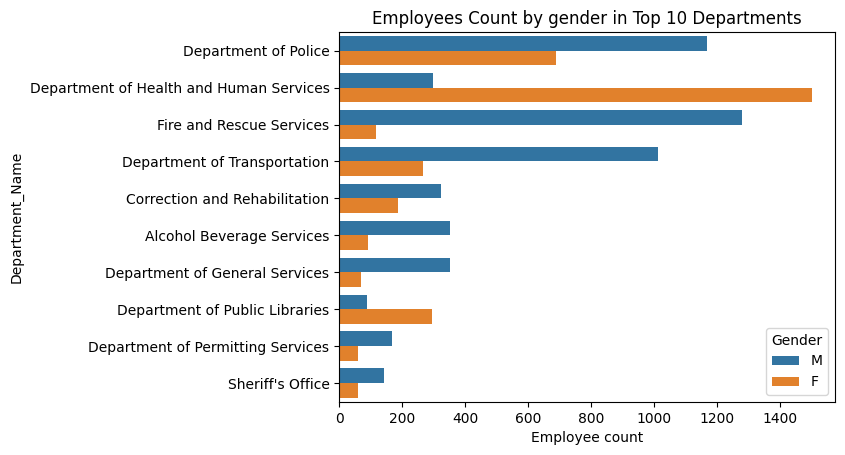

In [ ]:
sns.countplot(data=top10_departments, y = "Department_Name", hue = "Gender", order = top10_departments['Department_Name'].value_counts().index)
plt.title("Employees Count by gender in Top 10 Departments")
plt.xlabel("Employee count")
plt.show()

So, after exploring, cleaning, and preparing we went ahead and made this grouped bar chart that shows employee count by gender for the top 10 most populated departments. From this plot we can see right away that there is a significant gender imbalance in departments, most notably Department of Health and Human Services (with Females dominating) and Fire and Rescue services (with Males dominating). There are also other departments with major gender imbalances such as Department of Police, Department of Transportation, and Department of general services. Based on this plot, we can conclude that almost every department are male dominated with the exception of Department of health and human services and libraries.

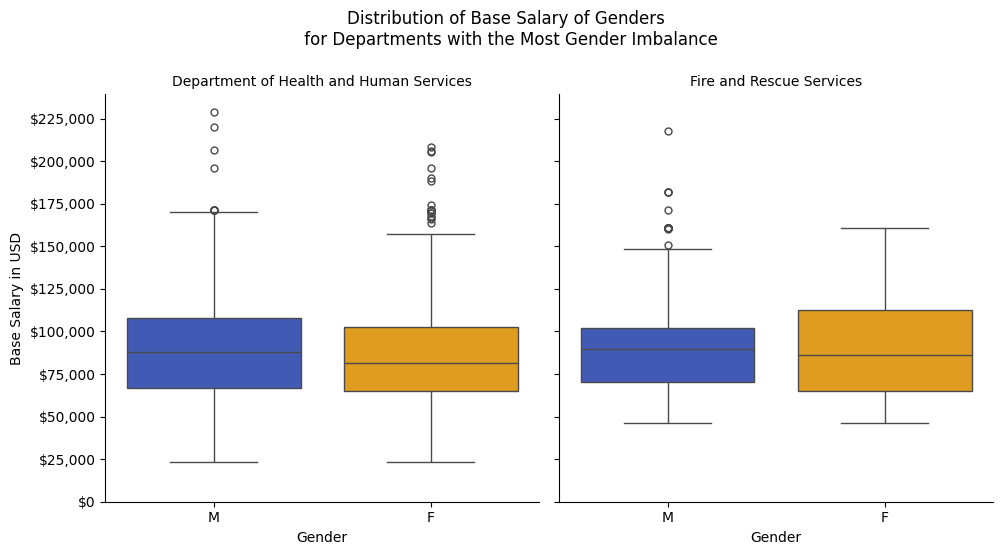

In [ ]:
two_deptdf = top10_departments[(top10_departments["Department_Name"] == "Department of Health and Human Services") | (top10_departments["Department_Name"] == "Fire and Rescue Services")] #creating a subset dataset with only the departments with huge gender misrepresntation
g = sns.catplot(data=two_deptdf,
              x = "Gender",
              y = "Base Salary",
              hue = "Gender",
              kind = "box",
              order = ["M", "F"],
              col = "Department_Name",
              palette = {"F": "orange", "M": "#2e51c7" }, # Applying  custom palette
              )
y_ticks = np.arange(0, 250000, 25000)
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
    ax.set_yticks(y_ticks)
g.set_axis_labels("Gender", "Base Salary in USD")
g.set_titles(col_template="{col_name}")
g.fig.suptitle("Distribution of Base Salary of Genders \n for Departments with the Most Gender Imbalance",x=0.5, y =1.1)
plt.show()

We then decided to take a closer look at the two departments with the most gender imbalances by examining the distribution of base salary for the two genders. Surprisingly, even though department of health and human services is significantly dominated by females, the base salary for males seems to be higher with even noticeable outliers. The median is slightly higher for males too. For fire and rescue services (which is the male dominated department) the distribution shows that the median salaries are slightly higher for males and highest individual salaries are also found among males. However, the 75th percentile for females is higher than for males, indicating that a substantial portion of female employees are in a relatively higher salary brackets within this department, even if the absolute top earners are male.

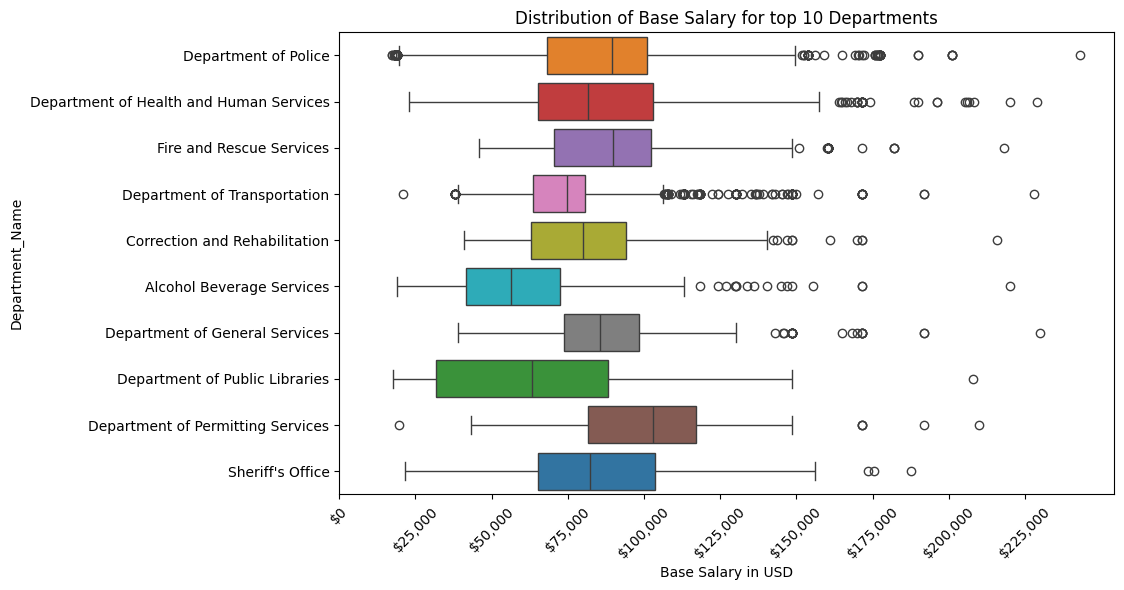

In [ ]:
plt.figure(figsize=(10, 6))
g3 = sns.boxplot(data = top10_departments,  x = "Base Salary", y = "Department_Name", hue = "Department_Name", order = top10_departments['Department_Name'].value_counts().index)

plt.title("Distribution of Base Salary for top 10 Departments")
plt.xlabel("Base Salary in USD")
x_ticks = np.arange(0, 250000, 25000)
g3.xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
g3.set_xticks(x_ticks)
plt.xticks(rotation = 45)
plt.show()

Next, we made this boxplot that shows distribution of base salary for each of the top 10 populated departments. Department of permitting services appears to have the highest median and 75th percentile amongst the top 10 departments, which suggests a higher pay scale. Alcohol Beverage services and department of public libraries show the lowest median and indivdual salaries, showing that these departments typically offer lower compensation compared to others. Departments of police and public libraries show a wide range of salaries within these departments, meaning there's a significant difference between the lowest and highest earners. In contrast, Department of Transportation has a lower standard deviation indicating a more consistent salary structure with less variability. Several departments show a large gap between their 75th percentile and maximum salary, or between their minimum and 25th percentile, which would be visually represented as outliers in the boxplot. In summary, the boxplot reveals clear differences in salary distributions across departments. Some departments consistently pay higher, while others have lower overall compensation but can still have individual roles with very high salaries.

# IV.Creating Model with Scikit

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder

**Encode Department_Name and Gender (Label Encoding)**

In [ ]:
#Encoding explanatory variables with sklearn
name = ['Department_Name','Gender']
def encode_feature(name):
    le = LabelEncoder()
    enc = le.fit([str(it) for it in final_df[name]]) #list comprehension for encoding each variable in data column
    le.classes_
    mapping = {cls: idx for idx, cls in enumerate(le.classes_)}
    return enc.transform(final_df[name]), mapping

In [ ]:
#dictionaries for later use
x1, dept_dict =encode_feature('Department_Name')
x2, gender_dict =encode_feature('Gender')

In [ ]:
#defining explanatory and target variables
X = pd.DataFrame({
    'Department_Name': x1,
    'Gender': x2
})
y=final_df[['Base Salary']]

In [ ]:
SEED=42

In [ ]:
#splitting training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=SEED)

In [ ]:
dt_regressor=DecisionTreeRegressor(max_depth=4,min_samples_leaf=.14,random_state=SEED)

In [ ]:
dt_regressor.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, min_samples_leaf=0.14, random_state=42)

In [ ]:
# Predictions on the test set
y_pred = dt_regressor.predict(X_test)

Create and Interpret Metric(s) of Model

In [ ]:
# Importation of appropriate regression metric
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score

In [ ]:

# Regression performance metrics computation
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)**(1/2)
mae = mean_absolute_error(y_test, y_pred)
CVRMSE = cross_val_score(dt_regressor,X_train,y_train, scoring='neg_root_mean_squared_error', cv=10)

print("R² Score:", r2)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)
print("CV RMSE:", CVRMSE)


R² Score: 0.07942750614849681
Mean Squared Error (MSE): 684645855.1953157
Root Mean Squared Error (RMSE): 26165.738193204405
Mean Absolute Error (MAE): 19773.468400866714
CV RMSE: [-27555.77909018 -27576.41390574 -28302.34379571 -26577.40408105
 -28142.84924106 -26115.97277965 -28746.18604634 -26927.04926755
 -25836.76000444 -29293.89459738]


In [ ]:
print(CVRMSE.mean())

-27331.12026018493


The decision tree regression model shows limited predictive performance.
With an R² of approximately 0.08, the model explains only a small fraction of the variability in base salaries.
The average prediction error is substantial (MAE ≈ $19,773, RMSE ≈ $26,165), indicating that salary is influenced by additional factors not captured in the model.
These results suggest that while the model detects some patterns, it is not reliable for accurate salary prediction.

In addition, the CVRMSE score across all 10 folds has a mean of 27507. That's a substantial difference in salary that makes this model a poor predictor of base salary based on the two explanatory variables Gender and Department.

# Prediction Table Sample

In [ ]:
x1, dept_dict =encode_feature('Department_Name')
x2, gender_dict= encode_feature('Gender')

dept_dict_inverse = {v: k for k, v in dept_dict.items()}
gender_dict_inverse = {v: k for k, v in gender_dict.items()}

In [ ]:
pred_table = X_test.copy()
pred_table['Department_Name_decoded'] = pred_table['Department_Name'].map(dept_dict_inverse)
pred_table['Gender_decoded']=pred_table['Gender'].map(gender_dict_inverse)
pred_table['Prediction']= y_pred
pred_table['Actual']= y_test['Base Salary'].values
print(pred_table)

      Department_Name  Gender                  Department_Name_decoded  \
7499                2       1           Department of General Services   
7310                2       1           Department of General Services   
2571                3       0  Department of Health and Human Services   
1084                5       0                     Department of Police   
856                 5       1                     Department of Police   
...               ...     ...                                      ...   
3393                3       1  Department of Health and Human Services   
6564                7       1             Department of Transportation   
2199                6       0           Department of Public Libraries   
4192                3       1  Department of Health and Human Services   
1784                5       0                     Department of Police   

     Gender_decoded    Prediction     Actual  
7499              M  75980.992610   59506.00  
7310             

Here is a sample comparing the predictions and actual test data for base salary based on the decoded explanatory variables.

# VI. Plot tree

In [ ]:
#tree.plot_tree use after training model

In [ ]:
from sklearn.tree import plot_tree

[Text(0.6666666666666666, 0.9, 'Department <= 7.5\nsquared_error = 811430717.749\nsamples = 6390\nvalue = 82664.004'),
 Text(0.5, 0.7, 'Department <= 5.5\nsquared_error = 824502728.853\nsamples = 5186\nvalue = 80873.945'),
 Text(0.5833333333333333, 0.8, 'True  '),
 Text(0.3333333333333333, 0.5, 'Department <= 2.5\nsquared_error = 851173479.614\nsamples = 3949\nvalue = 83120.865'),
 Text(0.16666666666666666, 0.3, 'squared_error = 814210607.264\nsamples = 1027\nvalue = 75980.993'),
 Text(0.5, 0.3, 'Gender <= 0.5\nsquared_error = 839950237.909\nsamples = 2922\nvalue = 85630.327'),
 Text(0.3333333333333333, 0.1, 'squared_error = 843962326.817\nsamples = 1703\nvalue = 80514.512'),
 Text(0.6666666666666666, 0.1, 'squared_error = 746702178.139\nsamples = 1219\nvalue = 92777.36'),
 Text(0.6666666666666666, 0.5, 'squared_error = 671788744.263\nsamples = 1237\nvalue = 73700.874'),
 Text(0.8333333333333334, 0.7, 'squared_error = 681874264.677\nsamples = 1204\nvalue = 90374.341'),
 Text(0.75, 0.8,

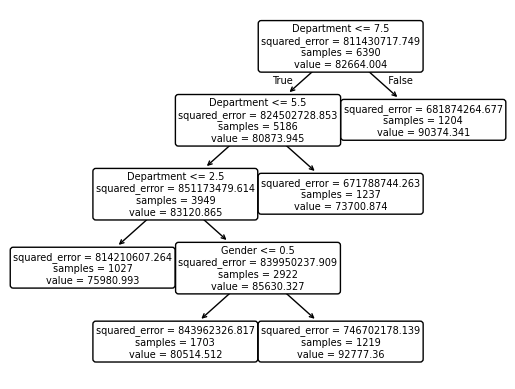

In [ ]:
plot_tree(dt_regressor, feature_names=['Department','Gender'], rounded=True)

Here we have the decision tree model printed out with all of its leaves and nodes. We start with 6390 samples from the training dataset, and slowly the decision tree finds the optimal place to split the data at each node to decrease the entropy of the dataset. For the first 3 branches the tree splits the data based on the variable Department Name or x[0]. In the last node, it splits the data by Gender x[1]. The squared error at each node is massive, indicating that the model is a poor predictor for base salary.

# VII. Interpret algorithmn Result + Conclusion

In this project, we analyzed the Montgomery County “Employee Salaries – 2022” dataset (over 10,000 records, 8 variables) to understand how well organizational and demographic factors predict pay. We cleaned and prepared the data by converting salary fields to numeric types and focusing on the top 10 departments by employee count. We explored the data visually, examining gender distributions across departments and comparing salary distributions by department and gender. Finally, we built a decision tree regression model using only Department_Name and Gender to predict base salary and evaluated it with metrics such as R^2, RMSE, and MAE. The model’s low explanatory power and large errors led us to conclude that while department and gender contain some signal, they are far from sufficient to accurately predict individual base salaries, implying that other factors like grade, role, and tenure likely play a much larger role.

The decision tree regression model using only Department\_Name and Gender to predict base salary performed poorly. It achieved an R^2 of about 0.08, meaning these two variables together explain only roughly 8\% of the variation in salaries. Error metrics were large relative to the average salary: RMSE was about \$26k–\$27k and MAE about \$20k, indicating that typical prediction errors are in the tens of thousands of dollars.

Structurally, the tree splits mostly on department and only once on gender, confirming that department provides more signal than gender. However, even within department–gender groups, the remaining salary variation is still very high. Tweaking the hyperparameters of the model may lead to better performance, but are unlikely to substantially improve the explanatory power of Gender and Department.

 Overall, this shows that while department and gender capture some broad patterns, they are not nearly sufficient on their own to reliably predict individual base salaries.